In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv', encoding='utf-8')
stores = pd.read_csv('stores.csv', encoding='utf-8')

print("Train shape:", df.shape)
print("Stores shape:", stores.shape)

Train shape: (3000888, 6)
Stores shape: (54, 5)


In [3]:
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

First 5 rows:
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Data types:
id               int64
date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object


In [4]:
# Step 1 - Drop id column
df = df.drop(columns=['id'])

# Step 2 - Convert date from string to datetime
df['date'] = pd.to_datetime(df['date'])

# Step 3 - Verify changes
print("Columns now:", df.columns.tolist())
print("\nDate type now:", df['date'].dtype)
print("\nDate range:")
print("Start:", df['date'].min())
print("End:", df['date'].max())
print("\nFirst 5 rows:")
print(df.head())

Columns now: ['date', 'store_nbr', 'family', 'sales', 'onpromotion']

Date type now: datetime64[us]

Date range:
Start: 2013-01-01 00:00:00
End: 2017-08-15 00:00:00

First 5 rows:
        date  store_nbr      family  sales  onpromotion
0 2013-01-01          1  AUTOMOTIVE    0.0            0
1 2013-01-01          1   BABY CARE    0.0            0
2 2013-01-01          1      BEAUTY    0.0            0
3 2013-01-01          1   BEVERAGES    0.0            0
4 2013-01-01          1       BOOKS    0.0            0


In [5]:
# Merge train data with stores data
df = df.merge(stores, on='store_nbr', how='left')

# Verify merge
print("Shape after merge:", df.shape)
print("\nNew columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape after merge: (3000888, 9)

New columns: ['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster']

First 5 rows:
        date  store_nbr      family  sales  onpromotion   city      state  \
0 2013-01-01          1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1 2013-01-01          1   BABY CARE    0.0            0  Quito  Pichincha   
2 2013-01-01          1      BEAUTY    0.0            0  Quito  Pichincha   
3 2013-01-01          1   BEVERAGES    0.0            0  Quito  Pichincha   
4 2013-01-01          1       BOOKS    0.0            0  Quito  Pichincha   

  type  cluster  
0    D       13  
1    D       13  
2    D       13  
3    D       13  
4    D       13  


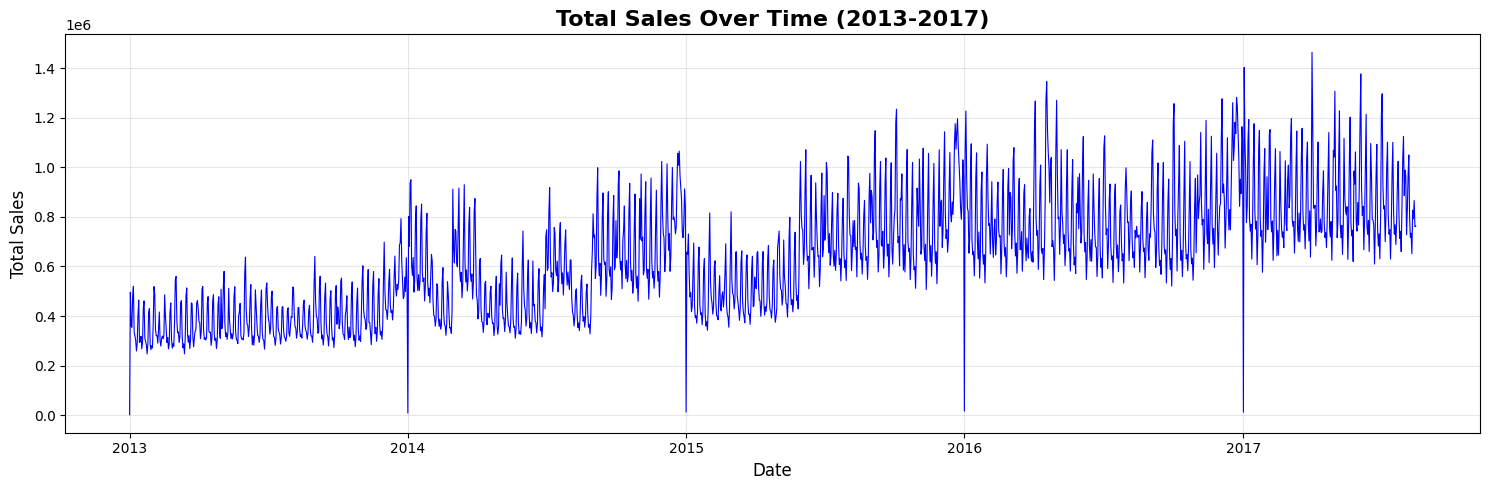

In [6]:
# Group sales by date
daily_sales = df.groupby('date')['sales'].sum().reset_index()

# Plot
plt.figure(figsize=(15, 5))
plt.plot(daily_sales['date'], 
         daily_sales['sales'], 
         color='blue', 
         linewidth=0.8)

plt.title('Total Sales Over Time (2013-2017)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150)
plt.show()

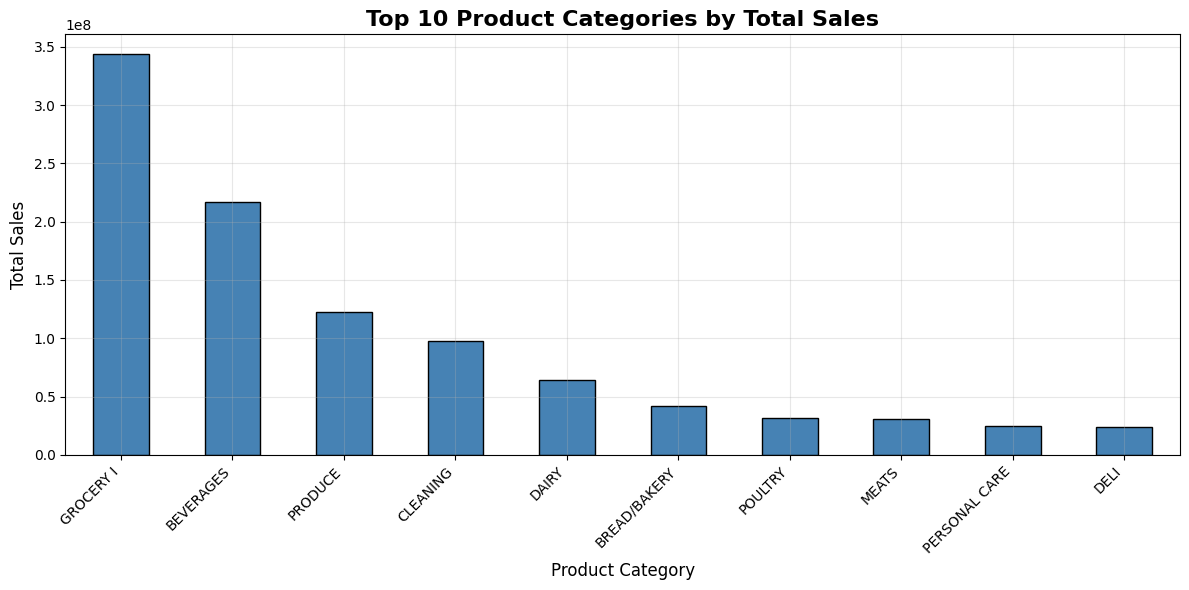

Top 10 categories:
family
GROCERY I        3.434627e+08
BEVERAGES        2.169545e+08
PRODUCE          1.227047e+08
CLEANING         9.752129e+07
DAIRY            6.448771e+07
BREAD/BAKERY     4.213395e+07
POULTRY          3.187600e+07
MEATS            3.108647e+07
PERSONAL CARE    2.459205e+07
DELI             2.411032e+07
Name: sales, dtype: float64


In [7]:
# Top 10 product families by total sales
family_sales = df.groupby('family')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
family_sales.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Top 10 Product Categories by Total Sales', 
          fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('category_sales.png', dpi=150)
plt.show()

print("Top 10 categories:")
print(family_sales)

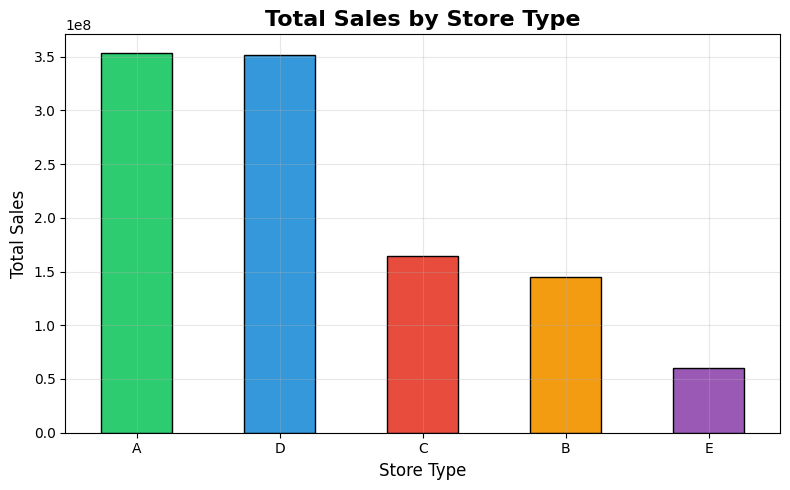

Sales by store type:
type
A    3.530438e+08
D    3.510833e+08
C    1.644347e+08
B    1.452606e+08
E    5.982244e+07
Name: sales, dtype: float64


In [8]:
# Sales by store type
store_sales = df.groupby('type')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
store_sales.plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6'], 
                edgecolor='black')

plt.title('Total Sales by Store Type', 
          fontsize=16, fontweight='bold')
plt.xlabel('Store Type', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('store_type_sales.png', dpi=150)
plt.show()

print("Sales by store type:")
print(store_sales)

In [9]:
# Extract time based features from date
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['quarter'] = df['date'].dt.quarter

# Encode store type
df['type_encoded'] = df['type'].map({'A':1,'B':2,'C':3,'D':4,'E':5})

# Encode family/category
df['family_encoded'] = df['family'].astype('category').cat.codes

# Verify
print("New columns added:")
print(df.columns.tolist())
print("\nSample data:")
print(df[['date','year','month','day','day_of_week',
          'is_weekend','quarter','type_encoded',
          'family_encoded']].head())

New columns added:
['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'is_weekend', 'quarter', 'type_encoded', 'family_encoded']

Sample data:
        date  year  month  day  day_of_week  is_weekend  quarter  \
0 2013-01-01  2013      1    1            1           0        1   
1 2013-01-01  2013      1    1            1           0        1   
2 2013-01-01  2013      1    1            1           0        1   
3 2013-01-01  2013      1    1            1           0        1   
4 2013-01-01  2013      1    1            1           0        1   

   type_encoded  family_encoded  
0             4               0  
1             4               1  
2             4               2  
3             4               3  
4             4               4  


In [10]:
from sklearn.model_selection import train_test_split

# Select features and target
features = ['store_nbr', 'family_encoded', 'onpromotion',
            'year', 'month', 'day', 'day_of_week',
            'week_of_year', 'is_weekend', 'quarter',
            'type_encoded', 'cluster']

X = df[features]
y = df['sales']

# Split data — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("\nFeatures used:", features)

Training size: (2400710, 12)
Testing size: (600178, 12)

Features used: ['store_nbr', 'family_encoded', 'onpromotion', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'is_weekend', 'quarter', 'type_encoded', 'cluster']


In [11]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Build model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

print("Training model... please wait")

# Train
xgb_model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=20)

print("\nModel training complete!")

Training model... please wait
[0]	validation_0-rmse:1047.71766
[20]	validation_0-rmse:575.74549
[40]	validation_0-rmse:489.28726
[60]	validation_0-rmse:454.29316
[80]	validation_0-rmse:430.19392
[99]	validation_0-rmse:415.14715

Model training complete!


MODEL EVALUATION RESULTS
RMSE : 415.15
MAE  : 140.87

Feature Importance:
           Feature  Importance
2      onpromotion    0.296475
10    type_encoded    0.184753
1   family_encoded    0.175090
3             year    0.100846
6      day_of_week    0.076104
0        store_nbr    0.062928
11         cluster    0.045776
4            month    0.022166
5              day    0.020394
7     week_of_year    0.015468
9          quarter    0.000000
8       is_weekend    0.000000


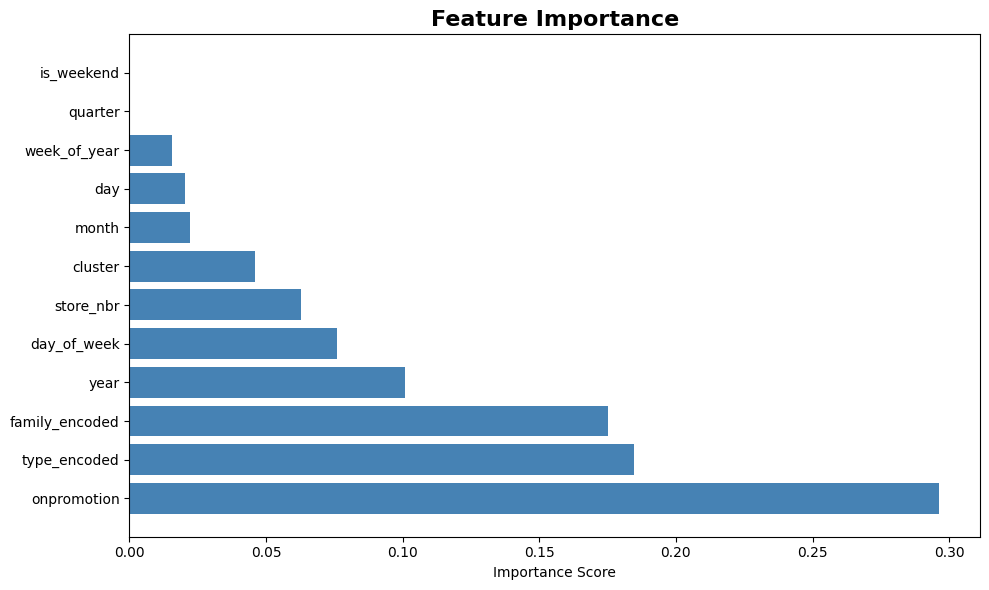

In [12]:
# Make predictions
y_pred = xgb_model.predict(X_test)

# Calculate errors
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("="*40)
print("MODEL EVALUATION RESULTS")
print("="*40)
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print("="*40)

# Feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], 
         importance['Importance'],
         color='steelblue')
plt.title('Feature Importance', 
          fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

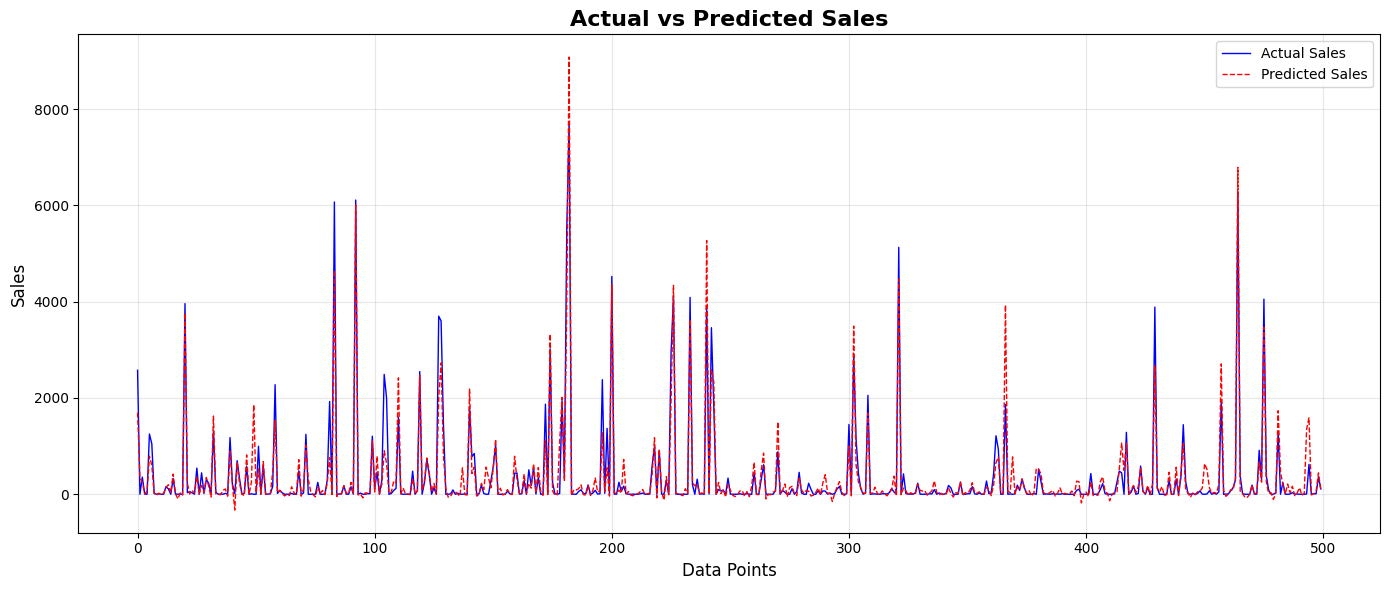

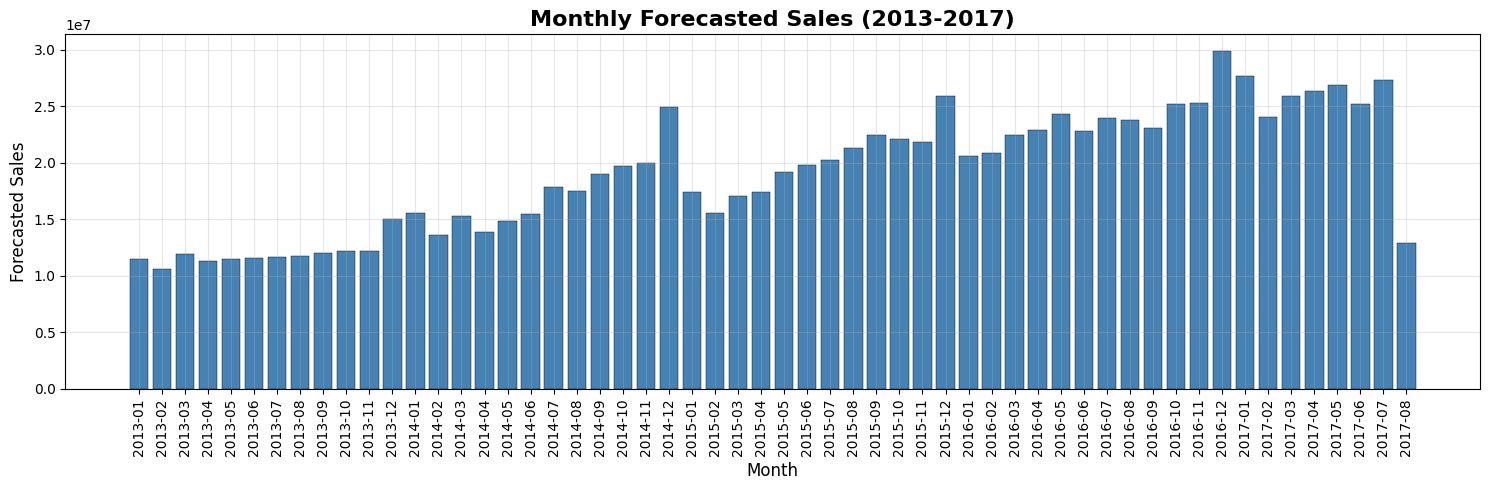

Forecast charts saved!


In [13]:
# Compare actual vs predicted
plt.figure(figsize=(14, 6))

# Take sample of 500 points for clear visualization
sample_idx = range(0, 500)
plt.plot(y_test.values[:500], 
         label='Actual Sales', 
         color='blue', 
         linewidth=1)
plt.plot(y_pred[:500], 
         label='Predicted Sales', 
         color='red', 
         linewidth=1,
         linestyle='--')

plt.title('Actual vs Predicted Sales', 
          fontsize=16, fontweight='bold')
plt.xlabel('Data Points', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

# Monthly forecast summary
df['predicted_sales'] = xgb_model.predict(df[features])
monthly = df.groupby(['year','month'])['predicted_sales'].sum().reset_index()
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

plt.figure(figsize=(15, 5))
plt.bar(monthly['period'], 
        monthly['predicted_sales'],
        color='steelblue',
        edgecolor='black',
        linewidth=0.3)
plt.title('Monthly Forecasted Sales (2013-2017)',
          fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Forecasted Sales', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_forecast.png', dpi=150)
plt.show()

print("Forecast charts saved!")

In [ ]:
import google.generativeai as genai

# Configure Gemini
genai.configure(api_key="your_api_key_here")

# Prepare summary data
top_category = "GROCERY I"
top_store_type = "A"
total_forecast_2017 = df[df['year']==2017]['predicted_sales'].sum()
growth = ((df[df['year']==2017]['predicted_sales'].sum() -
           df[df['year']==2013]['predicted_sales'].sum()) /
           df[df['year']==2013]['predicted_sales'].sum() * 100)

# Create prompt
prompt = f"""
You are a business analyst. Based on this retail sales data:
- Top selling category: {top_category}
- Best performing store type: {top_store_type}
- Peak sales month: December
- Total forecasted sales 2017: {total_forecast_2017:,.0f}
- Sales growth from 2013 to 2017: {growth:.1f}%
- Promotions are the biggest driver of sales (30% importance)

Write 4 specific business insights and recommendations
for the store manager. Be specific and actionable.
"""

# Call Gemini AI
model = genai.GenerativeModel('gemini-2.5-flash')
response = model.generate_content(prompt)

# Print AI insights
print("="*50)
print("AI GENERATED BUSINESS INSIGHTS")
print("="*50)
print(response.text)

C:\Users\Hello\AppData\Local\Temp\ipykernel_4332\1126578842.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


AI GENERATED BUSINESS INSIGHTS
Here are 4 specific business insights and actionable recommendations for the store manager:

1.  **Insight: Maximize High-Impact Promotional Strategies on Top-Selling Products.**
    *   **Recommendation:** Given that promotions are the biggest driver of sales (30% importance) and "GROCERY I" is the top-selling category, dedicate a significant portion of your promotional budget and in-store display space to "GROCERY I" products, especially during high-traffic periods. Implement multi-buy deals, loyalty program bonuses, or limited-time offers specifically for popular GROCERY I items, and track their ROI closely to continuously optimize.

2.  **Insight: Strategic Pre-Planning for Peak Sales is Critical for Annual Targets.**
    *   **Recommendation:** With December being the peak sales month and a total forecasted sales of 196,332,000 for 2017, begin planning for the holiday season by **early Q3**. This includes optimizing inventory levels for "GROCERY I" a

In [15]:
# Save model
import pickle

with open('sales_forecast_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save AI insights to text file
with open('ai_insights.txt', 'w') as f:
    f.write("AI GENERATED BUSINESS INSIGHTS\n")
    f.write("="*50 + "\n")
    f.write(response.text)

# Save final dataframe sample
df.head(1000).to_csv('forecast_results.csv', index=False)

print("✅ Model saved — sales_forecast_model.pkl")
print("✅ AI insights saved — ai_insights.txt")
print("✅ Forecast results saved — forecast_results.csv")
print("\nAll files saved successfully!")

✅ Model saved — sales_forecast_model.pkl
✅ AI insights saved — ai_insights.txt
✅ Forecast results saved — forecast_results.csv

All files saved successfully!


✅ Model loaded successfully!

PREDICTED SALES FOR NEW DATA
   Store Store Type Month  Onpromotion Items  Predicted Sales
0      1          A  June                 10      2320.949951
1      2          B  June                  0       340.820007
2      3          C  June                  5       605.419983


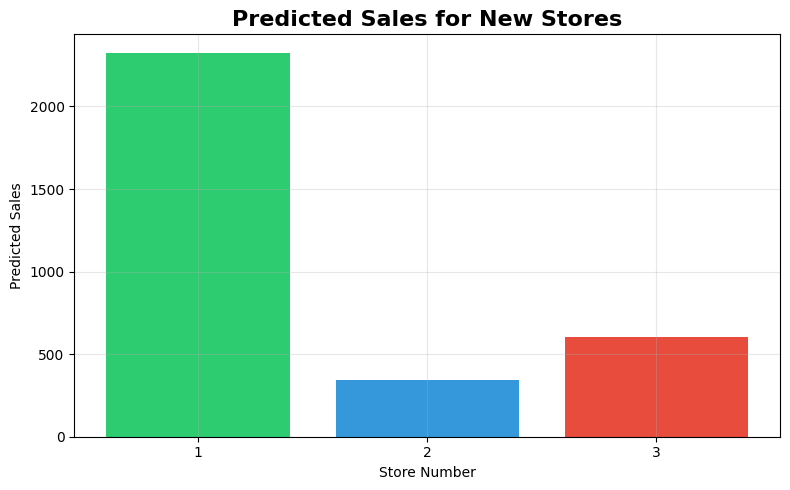


AI INSIGHTS FOR NEW PREDICTIONS
Here are 3 specific business insights and recommendations based on the June 2024 sales predictions:

## Business Insights & Recommendations for June 2024 Sales Predictions

**1. Store Needing Immediate Attention: Store 2 (Type B)**

*   **Insight:** Store 2 (Type B) is projected to generate only 341 units in sales, which is significantly lower than Store 3 (605 units) and a mere fraction (less than 15%) of Store 1's projected 2321 units. A critical factor distinguishing Store 2 is the complete absence of any promotional items.
*   **Recommendation:** Regional management must conduct an immediate, in-depth analysis of Store 2's performance. This investigation should go beyond promotions to include local market competition, store foot traffic, inventory levels, visual merchandising, and staff engagement. Simultaneously, a pilot program to introduce at least 5-7 targeted promotional items should be developed and implemented for July, specifically for Store

In [ ]:
import pandas as pd
import pickle
import google.generativeai as genai
import matplotlib.pyplot as plt

# Load saved model
with open('sales_forecast_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("✅ Model loaded successfully!")

# Create new sample data
new_data = pd.DataFrame({
    'store_nbr': [1, 2, 3],
    'family_encoded': [5, 10, 15],
    'onpromotion': [10, 0, 5],
    'year': [2024, 2024, 2024],
    'month': [6, 6, 6],
    'day': [1, 1, 1],
    'day_of_week': [5, 5, 5],
    'week_of_year': [22, 22, 22],
    'is_weekend': [1, 1, 1],
    'quarter': [2, 2, 2],
    'type_encoded': [1, 2, 3],
    'cluster': [13, 6, 3]
})

# Predict
predictions = loaded_model.predict(new_data)

# Show results
results = pd.DataFrame({
    'Store': [1, 2, 3],
    'Store Type': ['A', 'B', 'C'],
    'Month': ['June', 'June', 'June'],
    'Onpromotion Items': [10, 0, 5],
    'Predicted Sales': predictions.round(2)
})

print("\n" + "="*40)
print("PREDICTED SALES FOR NEW DATA")
print("="*40)
print(results)
print("="*40)

# Visualize predictions
plt.figure(figsize=(8, 5))
plt.bar(results['Store'].astype(str),
        results['Predicted Sales'],
        color=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Predicted Sales for New Stores',
          fontsize=16, fontweight='bold')
plt.xlabel('Store Number')
plt.ylabel('Predicted Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('new_prediction.png', dpi=150)
plt.show()

# ============================================
# AI INSIGHTS FOR NEW DATA PREDICTIONS
# ============================================
genai.configure(api_key="your_api_key_here")

gemini = genai.GenerativeModel('gemini-2.5-flash')

# Prepare prediction summary for AI
store1_sales = predictions[0].round(2)
store2_sales = predictions[1].round(2)
store3_sales = predictions[2].round(2)
best_store = results.loc[results['Predicted Sales'].idxmax(), 'Store']
best_sales = results['Predicted Sales'].max().round(2)

prompt = f"""
You are a retail business analyst. 
Here are sales predictions for 3 stores for June 2024:

- Store 1 (Type A) with 10 promotional items: {store1_sales} units
- Store 2 (Type B) with 0 promotional items: {store2_sales} units  
- Store 3 (Type C) with 5 promotional items: {store3_sales} units

Best performing store: Store {best_store} with {best_sales} units

Write 3 specific business insights and recommendations 
based on these predictions. Focus on:
1. Which store needs attention
2. Impact of promotions on sales
3. What store managers should do next month
"""

response_new = gemini.generate_content(prompt)

print("\n" + "="*50)
print("AI INSIGHTS FOR NEW PREDICTIONS")
print("="*50)
print(response_new.text)
print("="*50)